# Лабораторная работа 2

Прежде чем начать работать в jupyter notebook, я немного поработала с таблицей в Excel: удалила ненужные листы, открыла скрытые листы, а также перенесла часть таблицы, находящуюся справа от основной таблицы в конец на одном из листов, удалила изображение котика из середины таблицы.

In [10]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Предобработка данных

Подготовим датасет к работе: сделаем одну большую таблицу из всех листов таблицы, решим проблему с кодировкой.

In [11]:
xl = pd.ExcelFile("have_fun.xlsx", engine="openpyxl")
sheets = {sheet: xl.parse(sheet) for sheet in xl.sheet_names}

In [12]:
df = pd.concat(sheets.values(), ignore_index=True)
df["city"] = df["city"].apply(lambda x: x.encode("latin-1").decode("cp1251") if isinstance(x, str) else x)
df.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.8,82.0,0.0,0.0,0.0,3,19.1,1010.000000,2020-01-31 02:00:00,Геленджик
1,-3.0,70.0,0.0,0.0,0.0,3,24.0,981.900024,2025-02-28 09:00:00,Благовещенск
2,-1.3,86.0,0.0,0.0,0.0,2,8.8,1021.200012,2022-01-03 02:00:00,Геленджик
3,19.299999,49.0,0.0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик
4,9.6,89.0,0.0,0.0,0.0,0,8.8,1024.400024,2025-04-16 05:00:00,Геленджик


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373136 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        368122 non-null  object        
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         368497 non-null  object        
 3   rain                  370682 non-null  float64       
 4   snowfall              370682 non-null  float64       
 5   weathercode           370681 non-null  object        
 6   wind_speed_10m        369080 non-null  object        
 7   surface_pressure      370681 non-null  float64       
 8   ds                    370680 non-null  datetime64[us]
 9   city                  370678 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 28.5+ MB


Посмотрим на типы данных - нужно изменить тип данных для температуры, осадков, кода и скорости ветра. Также избавимся от пропущенных дат и городов - их нельзя заполнить, так как на вход даются не упорядоченные данные. 

In [14]:
df = df.dropna(subset=["ds"])
df = df.dropna(subset=["city"])
df['temperature_2m'] = pd.to_numeric(df['temperature_2m'], errors='coerce')
df['precipitation'] = pd.to_numeric(df['precipitation'], errors='coerce')
df['weathercode'] = pd.to_numeric(df['weathercode'], errors='coerce')
df['wind_speed_10m'] = pd.to_numeric(df['wind_speed_10m'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
Index: 370677 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366352 non-null  float64       
 1   relative_humidity_2m  370672 non-null  float64       
 2   precipitation         366972 non-null  float64       
 3   rain                  370677 non-null  float64       
 4   snowfall              370677 non-null  float64       
 5   weathercode           368836 non-null  float64       
 6   wind_speed_10m        367588 non-null  float64       
 7   surface_pressure      370677 non-null  float64       
 8   ds                    370677 non-null  datetime64[us]
 9   city                  370677 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 31.1 MB


Посмотрим на города, которые представлены в датасете и увидим, что некоторые названия повторяются из-за некорректной записи. Исправим это, в ручную заменив все неправильные названия на верные.

In [15]:
unique_cities = df['city'].unique()
print(unique_cities)
city_mapping = {
    'Геленджик': 'Геленджик',
    'ГЕЛЕНДЖИК': 'Геленджик',
    'геленджик': 'Геленджик',
    'Геленджикк': 'Геленджик',
    'Геленджи': 'Геленджик',
    'Благовещенск': 'Благовещенск',
    'БЛАГОВЕЩЕНСК': 'Благовещенск',
    'Благовещенс': 'Благовещенск',
    'Благовещенскк': 'Благовещенск',
    'благовещенск': 'Благовещенск',
    'Москва': 'Москва',
    'Мосва': 'Москва',
    'Санкт-Петербург': 'Санкт-Петербург',
    'Находка': 'Находка',
    'Сочи': 'Сочи',
    'Сычи': 'Сочи',
    'Счи': 'Сочи',
    'Соч': 'Сочи'
}
df['city'] = df['city'].map(city_mapping)
unique_cities = df['city'].unique()
print(unique_cities)

<StringArray>
[      'Геленджик',    'Благовещенск',    'БЛАГОВЕЩЕНСК',     'Благовещенс',
   'Благовещенскк',    'благовещенск',       'ГЕЛЕНДЖИК',       'геленджик',
      'Геленджикк',        'Геленджи',          'Москва',           'Мосва',
         'Находка', 'Санкт-Петербург',            'Сочи',            'Сычи',
             'Счи',             'Соч']
Length: 18, dtype: str
<StringArray>
['Геленджик', 'Благовещенск', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str


Разделим все данные по городам, отсортируем по дате и заполним пропуски с помощью линейной интерполяции.

In [16]:
city_dfs = {}
for city in unique_cities:
    city_dfs[city] = df[df['city'] == city].copy()

weather = ['temperature_2m', "relative_humidity_2m", "precipitation", "rain", "snowfall", "weathercode", "wind_speed_10m", "surface_pressure"]
for city, city_df in city_dfs.items():
    for col in weather:
        if col in city_df.columns:
            city_df[col] = city_df[col].interpolate(method='linear', limit_direction='both')
    df.loc[city_df.index, weather] = city_df[weather]
df.info()          
    

<class 'pandas.DataFrame'>
Index: 370677 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        370677 non-null  float64       
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         370677 non-null  float64       
 3   rain                  370677 non-null  float64       
 4   snowfall              370677 non-null  float64       
 5   weathercode           370677 non-null  float64       
 6   wind_speed_10m        370677 non-null  float64       
 7   surface_pressure      370677 non-null  float64       
 8   ds                    370677 non-null  datetime64[us]
 9   city                  370677 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 39.2 MB


Сгруппируем данные по городу и отсортируем по дате

In [17]:
for city, city_df in city_dfs.items():
    city_df.sort_values(by='ds', inplace=True)
    print(city)
    print(city_df.describe())

Геленджик
       temperature_2m  relative_humidity_2m  precipitation          rain  \
count    62559.000000          62559.000000   62559.000000  62559.000000   
mean        14.369291             74.440976       0.108141      0.102580   
min        -10.000000             16.000000       0.000000      0.000000   
25%          8.100000             64.000000       0.000000      0.000000   
50%         13.900000             78.000000       0.000000      0.000000   
75%         21.200001             88.000000       0.000000      0.000000   
max         37.799999            100.000000      18.000000     18.000000   
std          8.506980             17.121879       0.448307      0.442726   

           snowfall   weathercode  wind_speed_10m  surface_pressure  \
count  62559.000000  62559.000000    62559.000000      62559.000000   
mean       0.003874     11.077639       14.038245       1015.327975   
min        0.000000      0.000000        0.000000        987.000000   
25%        0.000000  

Изучим данные каждого города: видно, что появляются нереалистичные значения температуры и давления в Москве и Находке, также нереалистичное количество осадков в Москве. Поскольку снег и дождь в сумме дают количество осадков, заменим везде столбец с осадками на сумму дождя и снега и избавимся от повторяющихся данных.

In [18]:
for city, city_df in city_dfs.items():
    city_df.drop(columns=['precipitation'])
    city_df['precipitation'] = city_df['rain'] + city_df['snowfall']
    city_df = city_df.drop(columns=['rain', 'snowfall'])
    print(city_df.head())


       temperature_2m  relative_humidity_2m  precipitation  weathercode  \
45450             4.5                  94.0            0.3         51.0   
38752             4.3                  94.0            0.5         53.0   
57044             3.9                  96.0            0.1         51.0   
61685             4.6                  94.0            0.0          2.0   
48434             4.0                  96.0            0.0          2.0   

       wind_speed_10m  surface_pressure                  ds       city  
45450             5.5       1023.200012 2019-01-01 00:00:00  Геленджик  
38752             6.8       1023.500000 2019-01-01 01:00:00  Геленджик  
57044             7.7       1024.000000 2019-01-01 02:00:00  Геленджик  
61685             8.4       1023.799988 2019-01-01 03:00:00  Геленджик  
48434             9.5       1024.199951 2019-01-01 04:00:00  Геленджик  
        temperature_2m  relative_humidity_2m  precipitation  weathercode  \
5931             -13.7             

Посмотрим на значения в каждом городе. Видно, что во многих городах значения всех показателей находятся в пределах нормы. Странными являются значения температуры и давления в Москве и Находке.

Обработаем выбросы: изменим с помощью линейной интерполяции такие значения температуры и давления, которые отличаются от двух соседних больше, чем на 10, а также невозможные значения температуры 

In [19]:
for city, city_df in city_dfs.items():
    diff_prev = city_df['temperature_2m'].diff().abs()
    diff_next = city_df['temperature_2m'].diff(-1).abs()
    outliers = (diff_prev > 10) & (diff_next > 10)
    city_df.loc[outliers, 'temperature_2m'] = np.nan
    if city == "Москва":
        extr = abs(city_df['temperature_2m']) > 38
        city_df.loc[extr, 'temperature_2m'] = np.nan
    elif city == "Находка":
        extr = (city_df['temperature_2m'] > 37) | (city_df['temperature_2m'] < -27)
        city_df.loc[extr, 'temperature_2m'] = np.nan
    city_df['temperature_2m'] = city_df['temperature_2m'].interpolate(method='linear')

    diff_prev_pr = city_df['surface_pressure'].diff().abs()
    diff_next_pr = city_df['surface_pressure'].diff(-1).abs()
    outliers = (diff_prev_pr > 10) & (diff_next_pr > 10)
    city_df.loc[outliers, 'surface_pressure'] = np.nan
    city_df['surface_pressure'] = city_df['surface_pressure'].interpolate(method='linear')
    print(city)
    print(city_df.describe())

Геленджик
       temperature_2m  relative_humidity_2m  precipitation          rain  \
count    62559.000000          62559.000000   62559.000000  62559.000000   
mean        14.370099             74.440976       0.106454      0.102580   
min        -10.000000             16.000000       0.000000      0.000000   
25%          8.100000             64.000000       0.000000      0.000000   
50%         13.900000             78.000000       0.000000      0.000000   
75%         21.200001             88.000000       0.000000      0.000000   
max         37.799999            100.000000      18.000000     18.000000   
std          8.528744             17.121879       0.446196      0.442726   

           snowfall   weathercode  wind_speed_10m  surface_pressure  \
count  62559.000000  62559.000000    62559.000000      62559.000000   
mean       0.003874     11.077639       14.038245       1015.327975   
min        0.000000      0.000000        0.000000        987.000000   
25%        0.000000  

## Анализ временного ряда

Удалим дубликаты и посмотрим на данные по каждому городу

In [20]:
for city, city_df in city_dfs.items():
    city_df.dropna(subset=['ds'], inplace=True)
    city_df.drop_duplicates(subset=['ds'], inplace=True)

In [21]:
for city, city_df in city_dfs.items():
    print(city_df.info())

<class 'pandas.DataFrame'>
Index: 61368 entries, 45450 to 39816
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   temperature_2m        61368 non-null  float64       
 1   relative_humidity_2m  61368 non-null  float64       
 2   precipitation         61368 non-null  float64       
 3   rain                  61368 non-null  float64       
 4   snowfall              61368 non-null  float64       
 5   weathercode           61368 non-null  float64       
 6   wind_speed_10m        61368 non-null  float64       
 7   surface_pressure      61368 non-null  float64       
 8   ds                    61368 non-null  datetime64[us]
 9   city                  61368 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 5.2 MB
None
<class 'pandas.DataFrame'>
Index: 61368 entries, 5931 to 122539
Data columns (total 10 columns):
 #   Column                Non-Null Co

Посмотрим на то как изменяется температура с течением времени: сделаем визуализацию, используя скользящее среднее для каждого города 

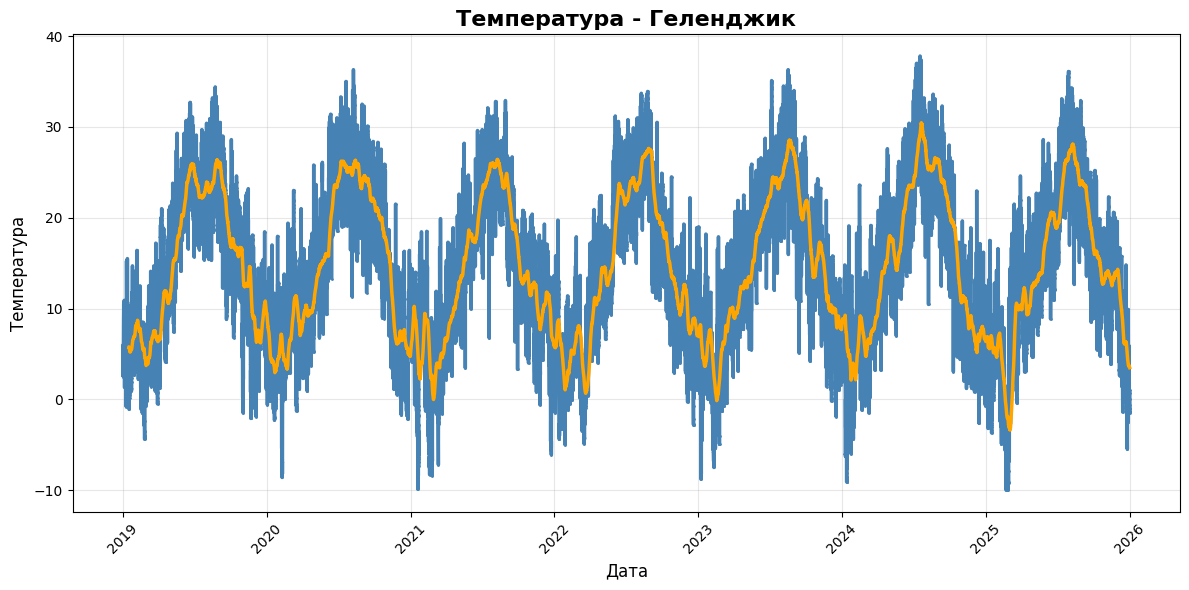

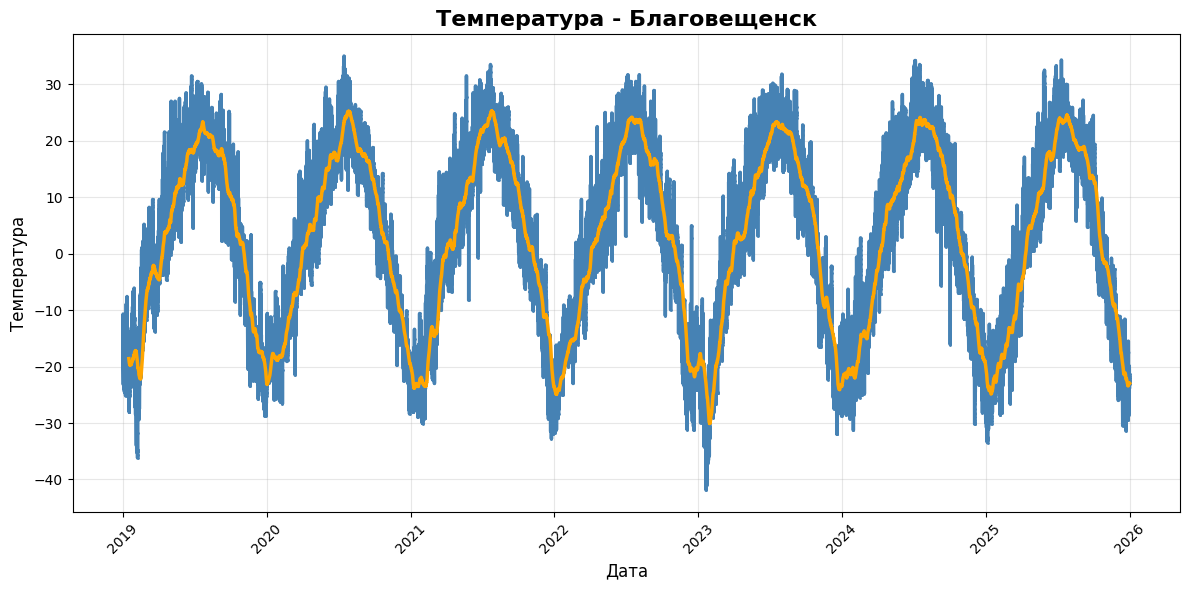

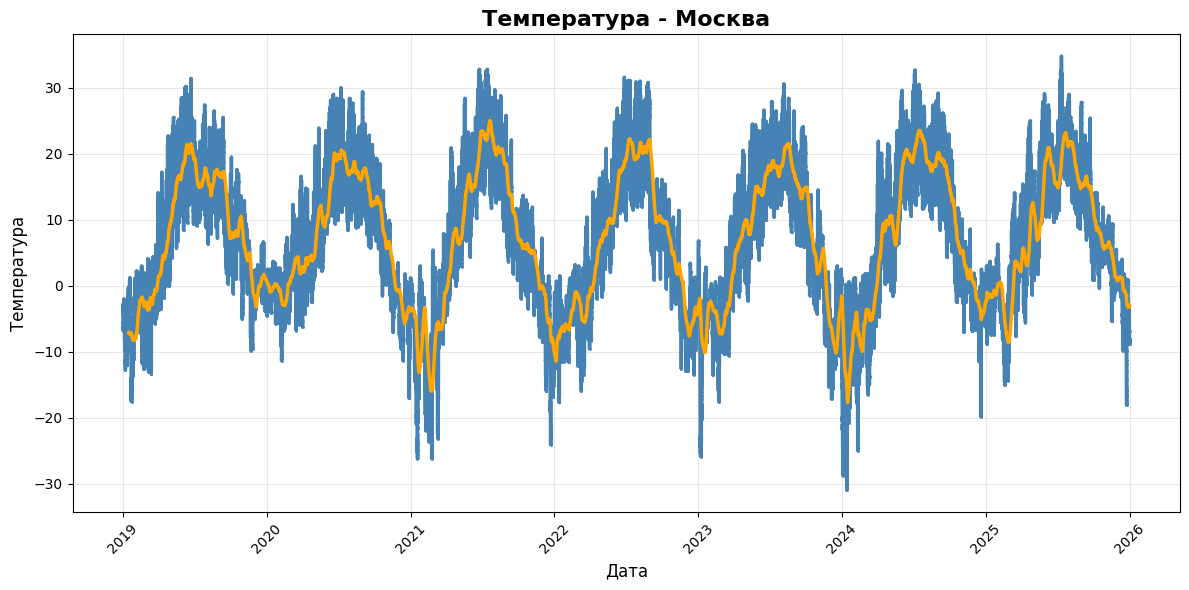

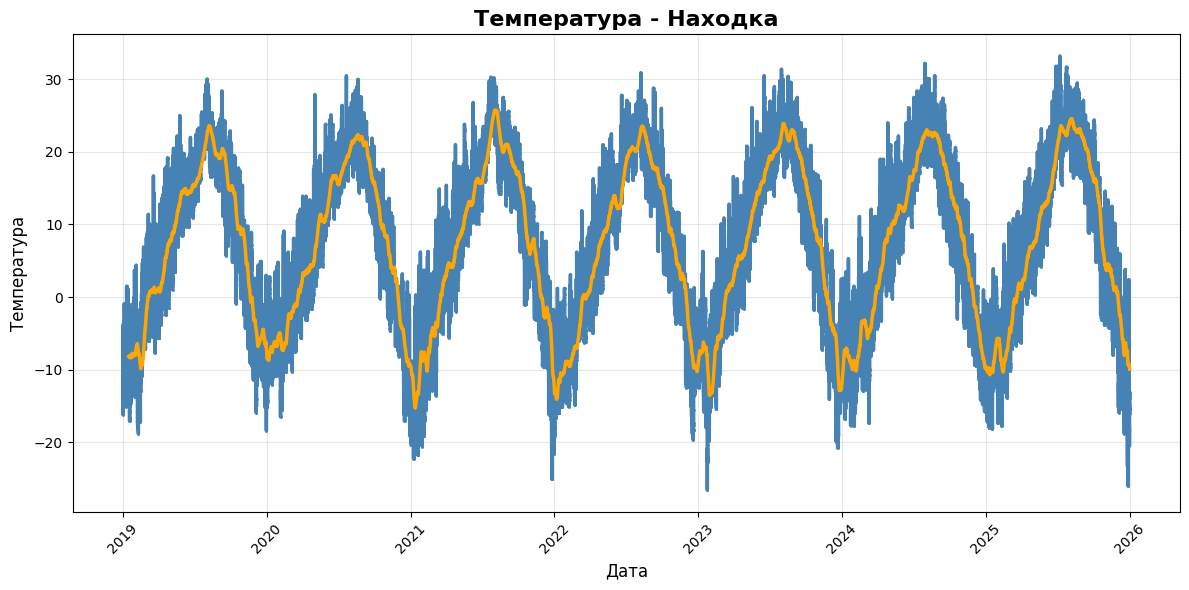

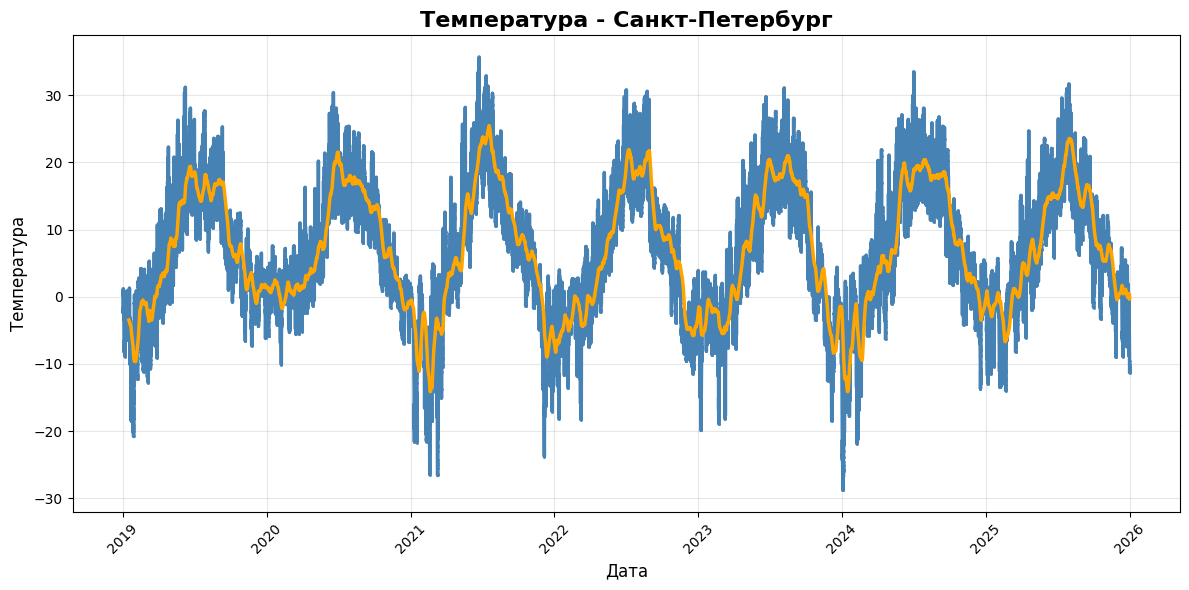

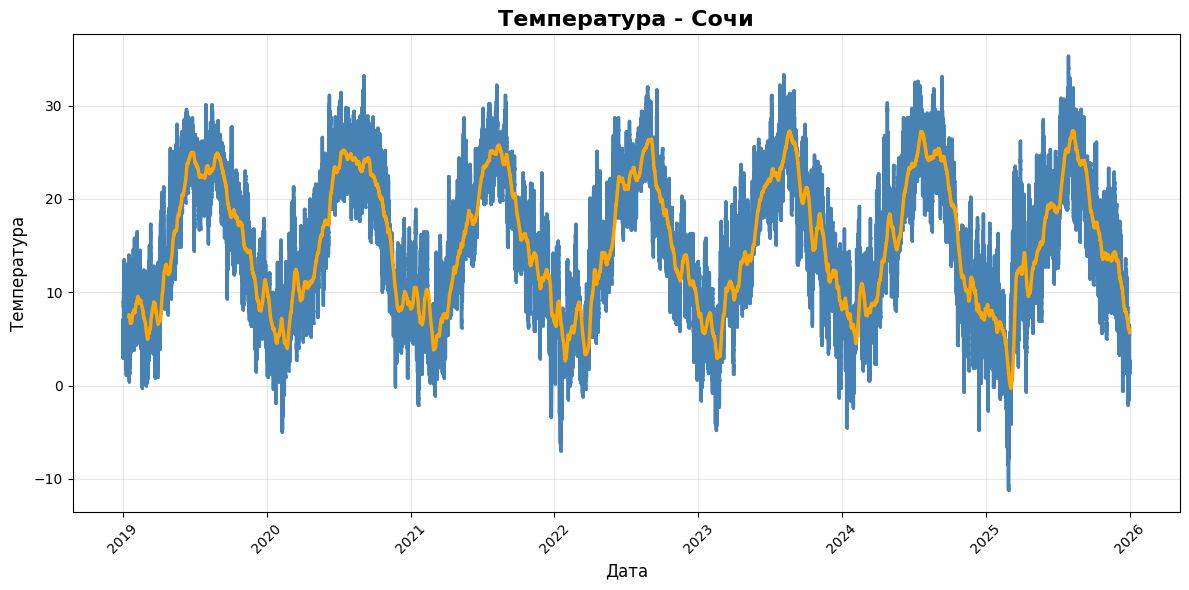

In [22]:
for city, city_df in city_dfs.items():
    plt.figure(figsize=(12, 6))
    plt.plot(city_df['ds'], city_df['temperature_2m'], linestyle='-', linewidth=2.5,  marker='.', markersize=2, color='steelblue')  
    plt.plot(city_df['ds'], city_df['temperature_2m'].rolling(window=365).mean(), linewidth=2.5, color='orange', label='Скользящее среднее за 12 месяцев')
    plt.title(f'Температура - {city}', fontsize=16, fontweight='bold')
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Температура', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Проведем тест Дики-Фуллера для проверки ряда на стационарность: p-value < 0.5 в каждом городе, значит ряд стационарен и нет необходимости в его дифференцировании.

In [23]:
from statsmodels.tsa.stattools import adfuller

for city, city_df in city_dfs.items():
    result = adfuller(city_df["temperature_2m"].dropna())
    print(city)
    print(f"p-value: {result[1]:.10f}")


Геленджик
p-value: 0.0000000005
Благовещенск
p-value: 0.0019682137
Москва
p-value: 0.0000000513
Находка
p-value: 0.0000290977
Санкт-Петербург
p-value: 0.0000001324
Сочи
p-value: 0.0000000195


Посмотрим на тренд, сезонность и остатки для каждого города, для наглдядности возьмем последние 30 дней. Четко видна ежедневная сезонность в каждом городе - днем температура больше, чем ночью 

Геленджик


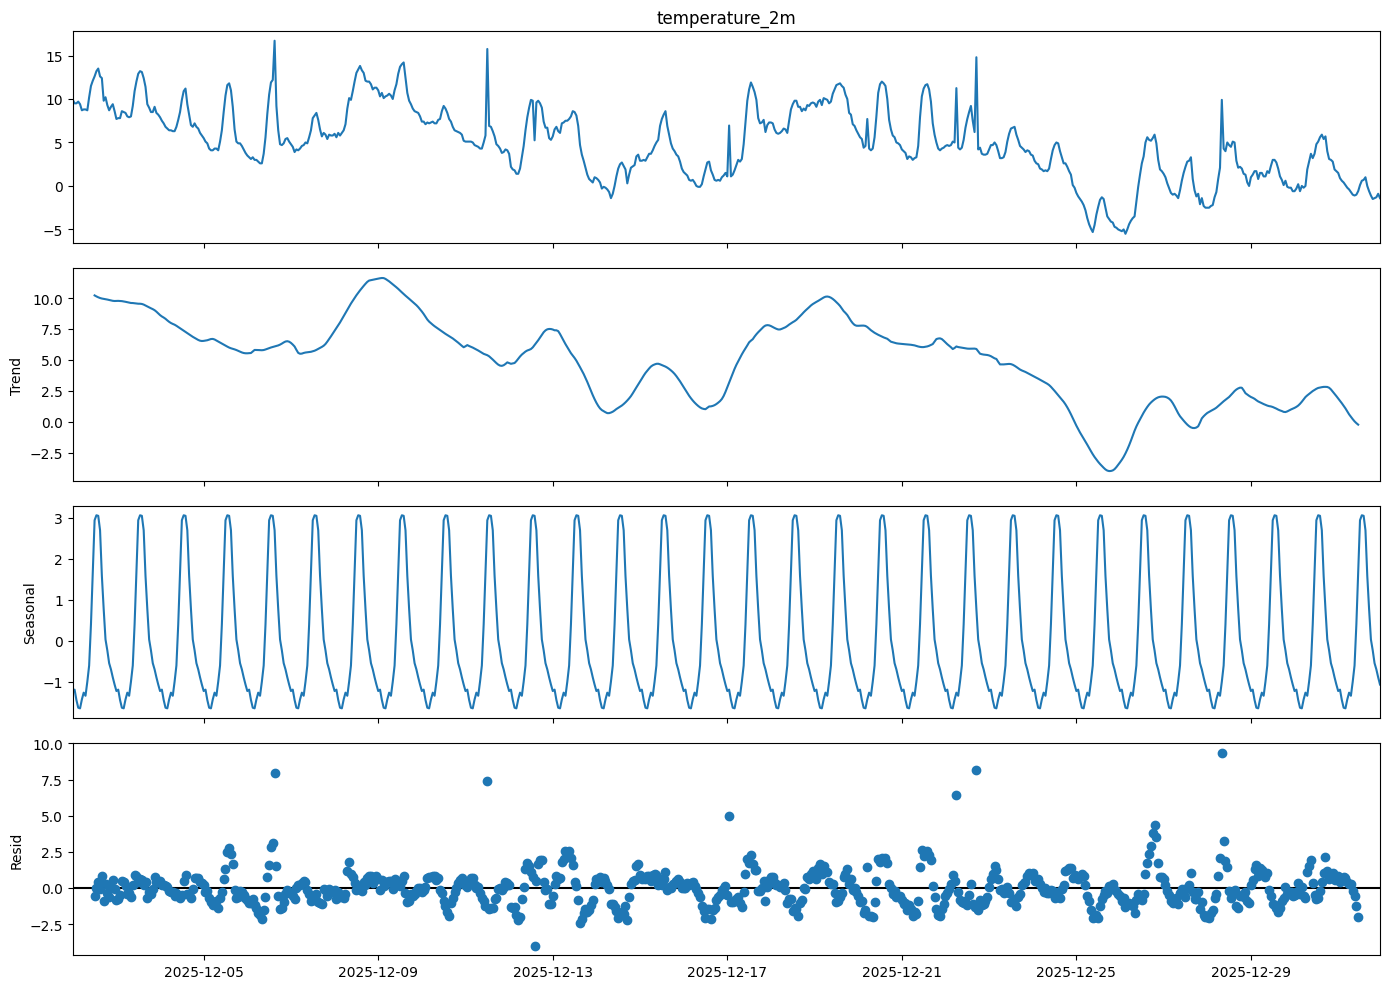

Благовещенск


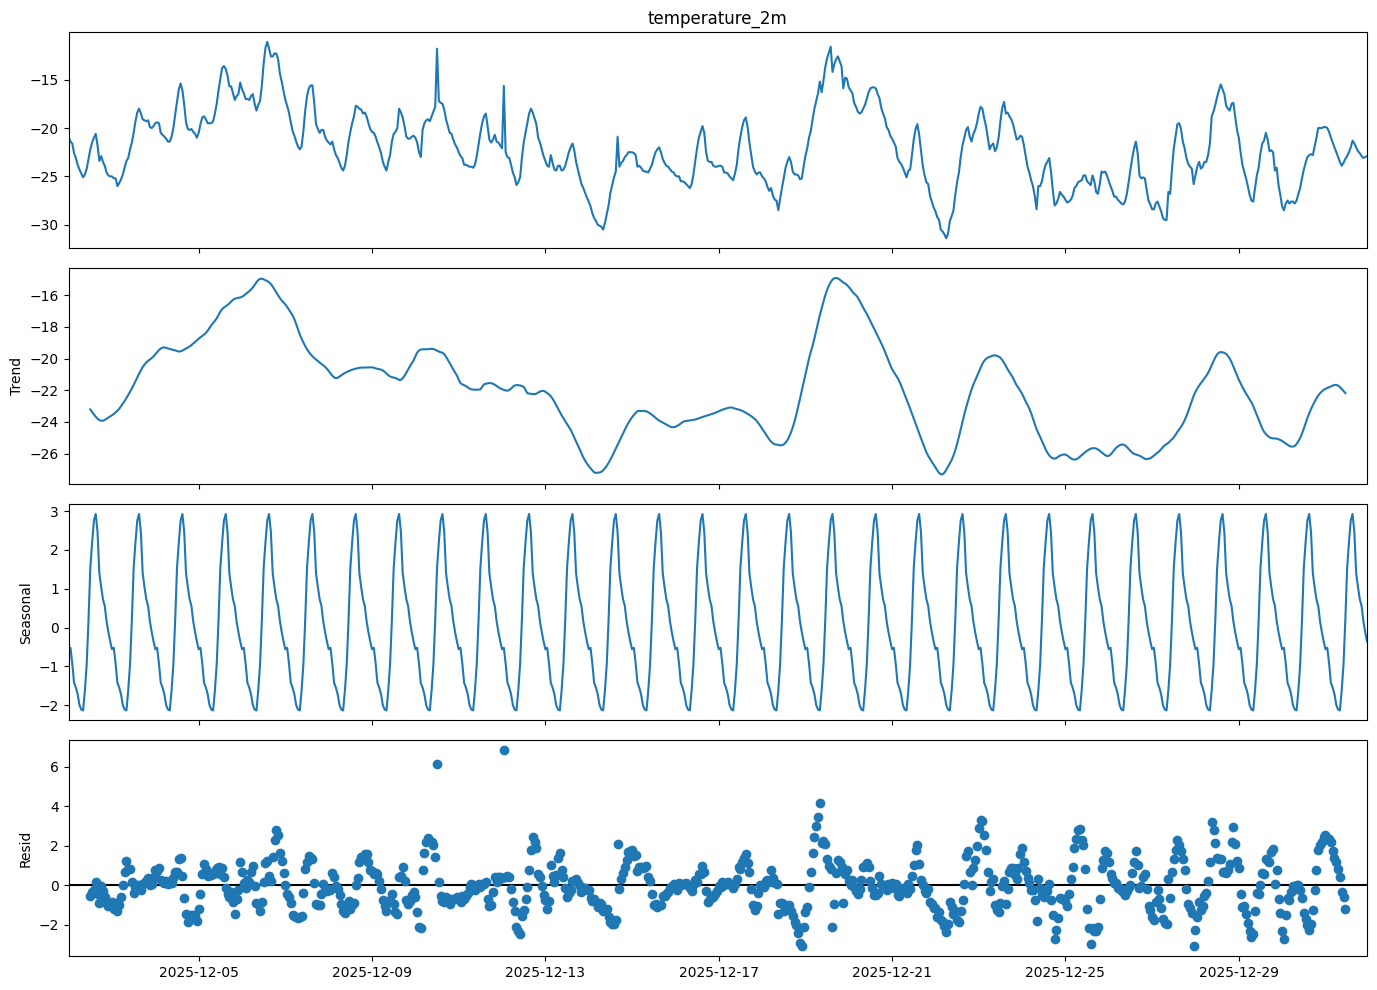

Москва


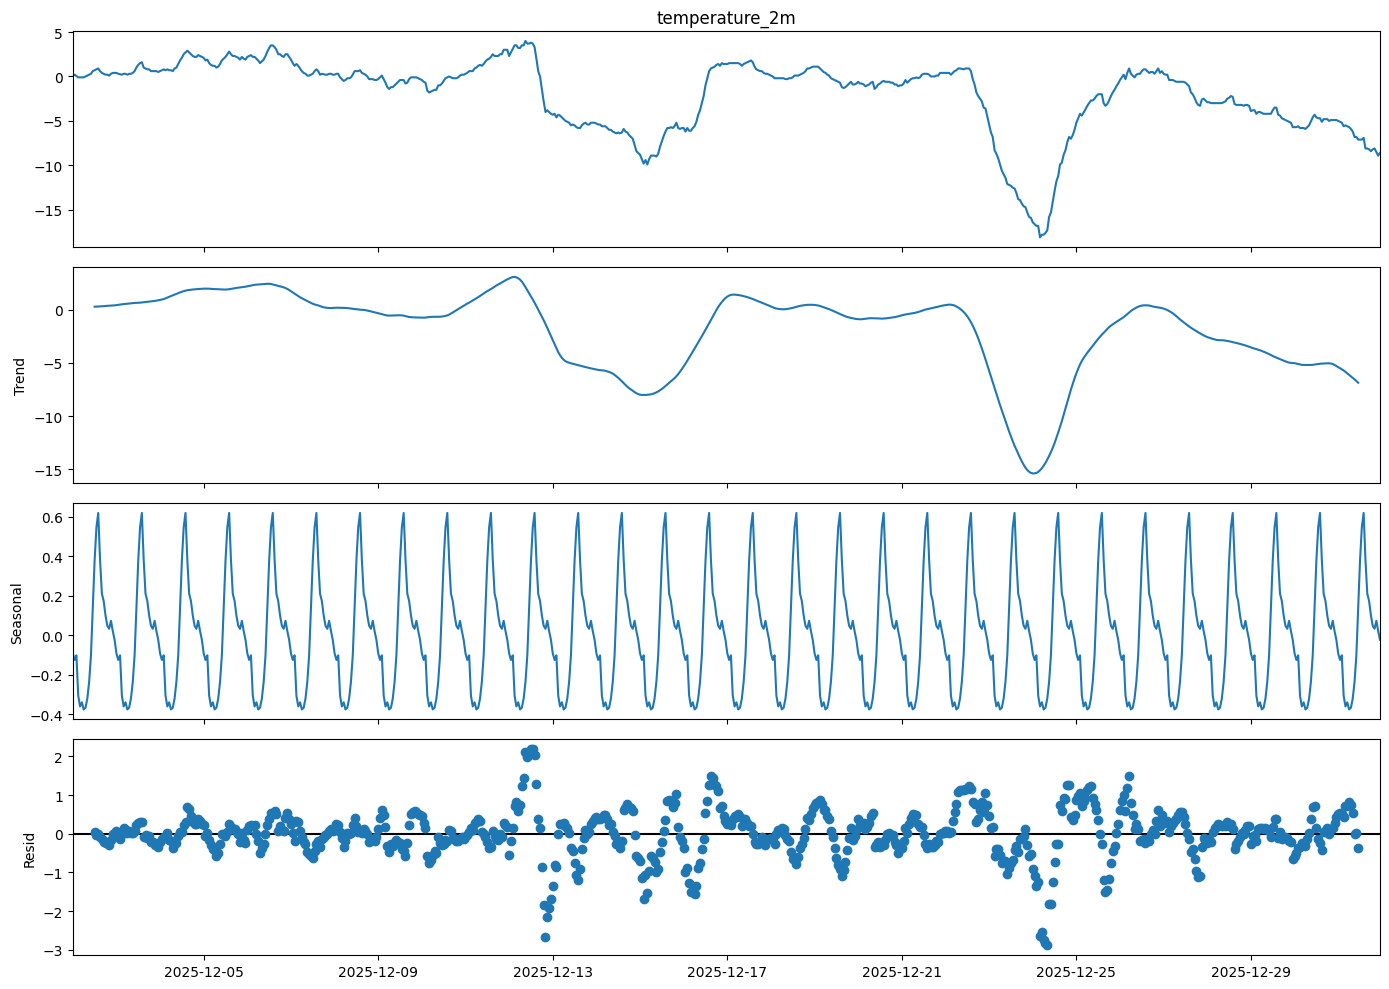

Находка


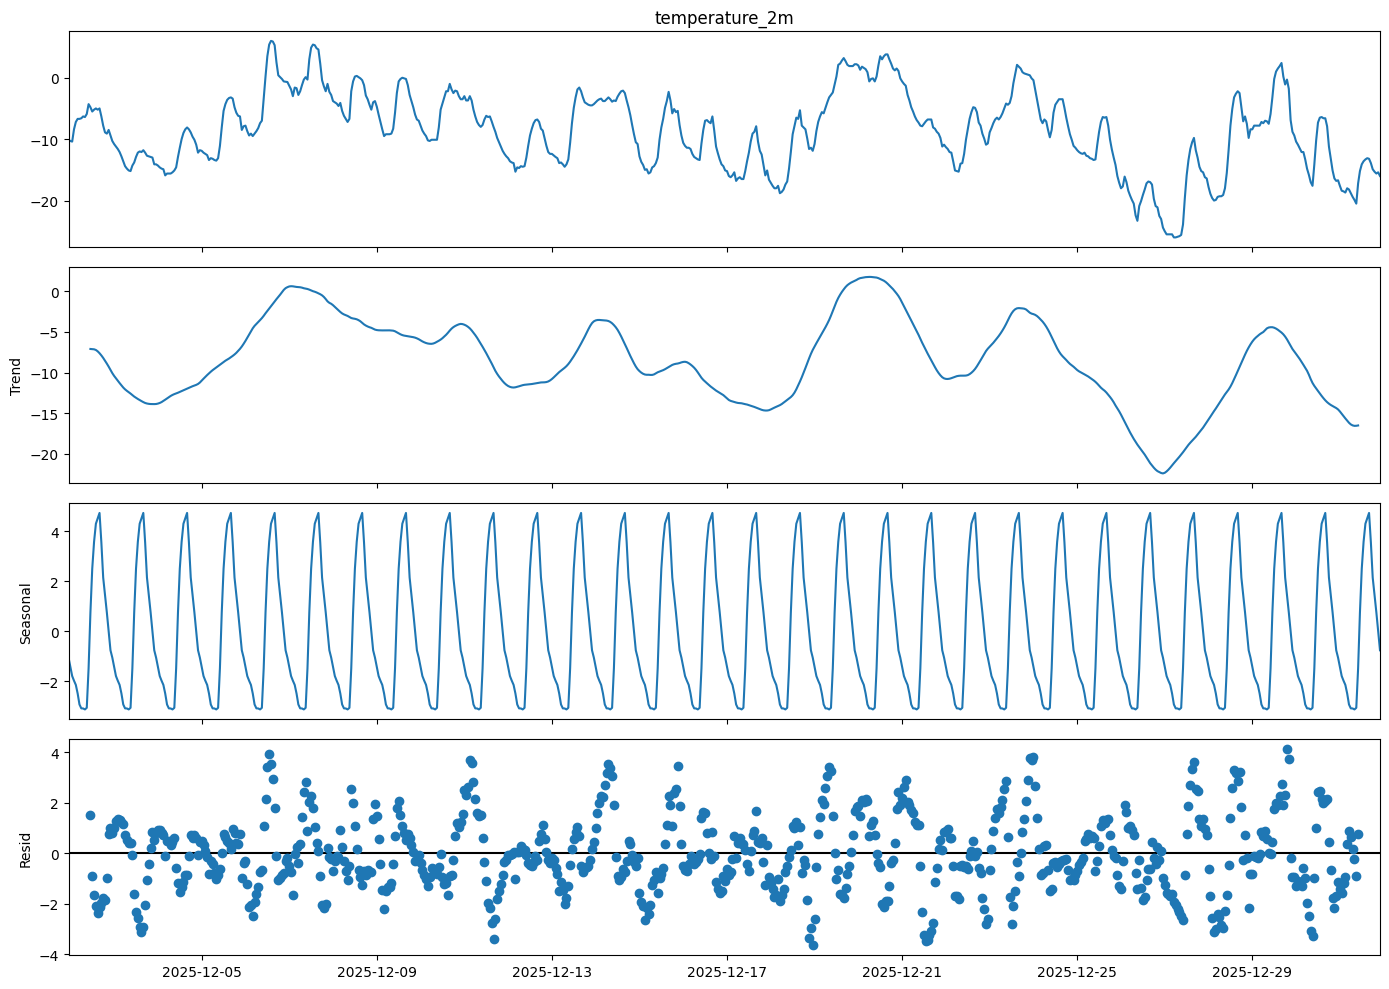

Санкт-Петербург


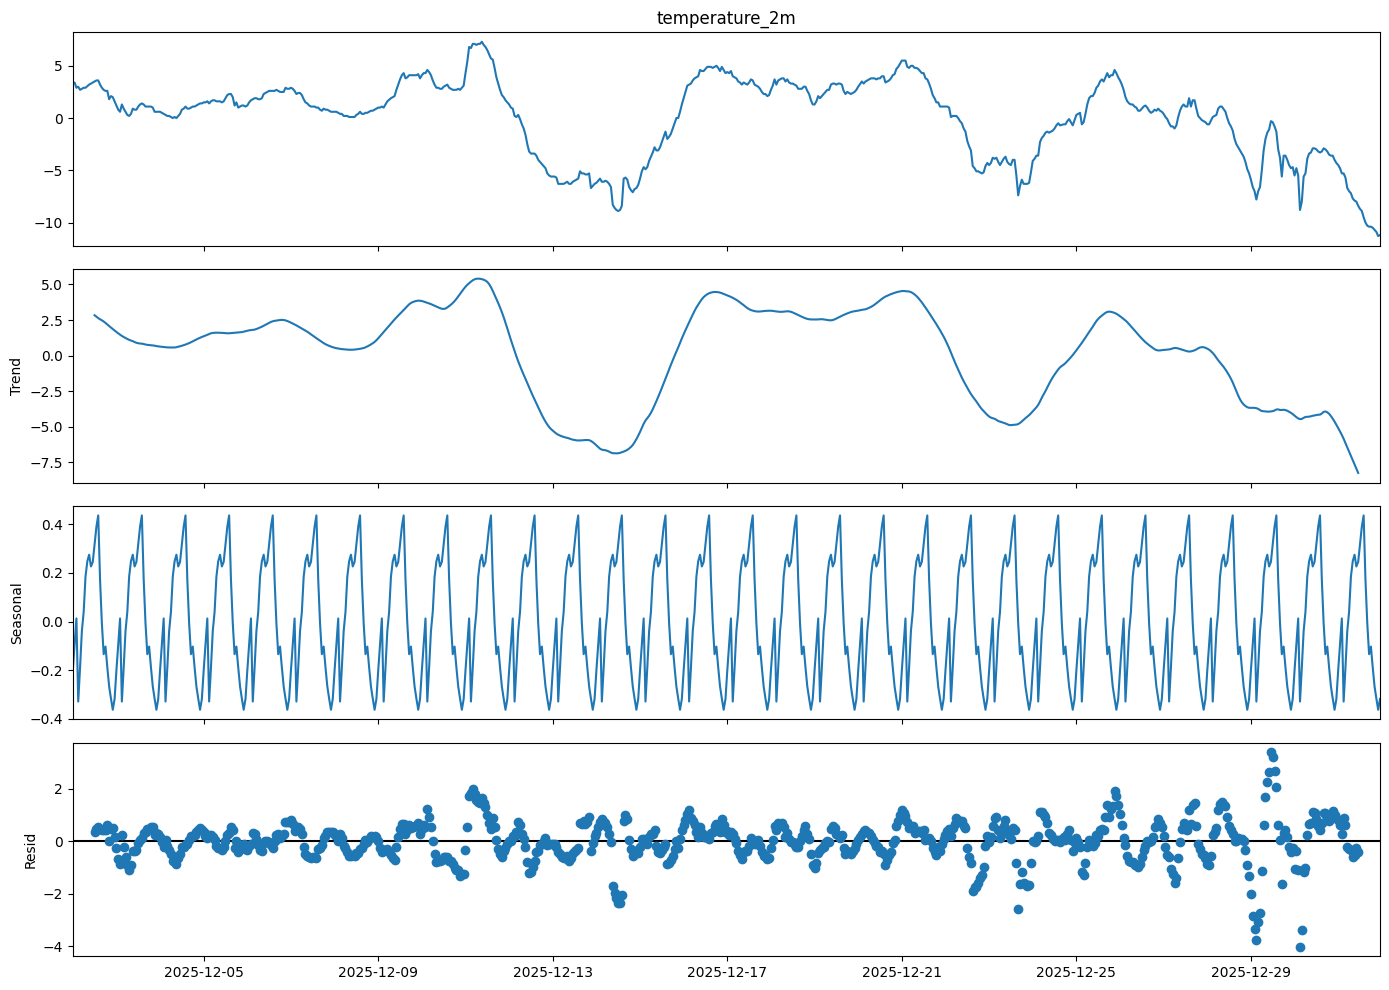

Сочи


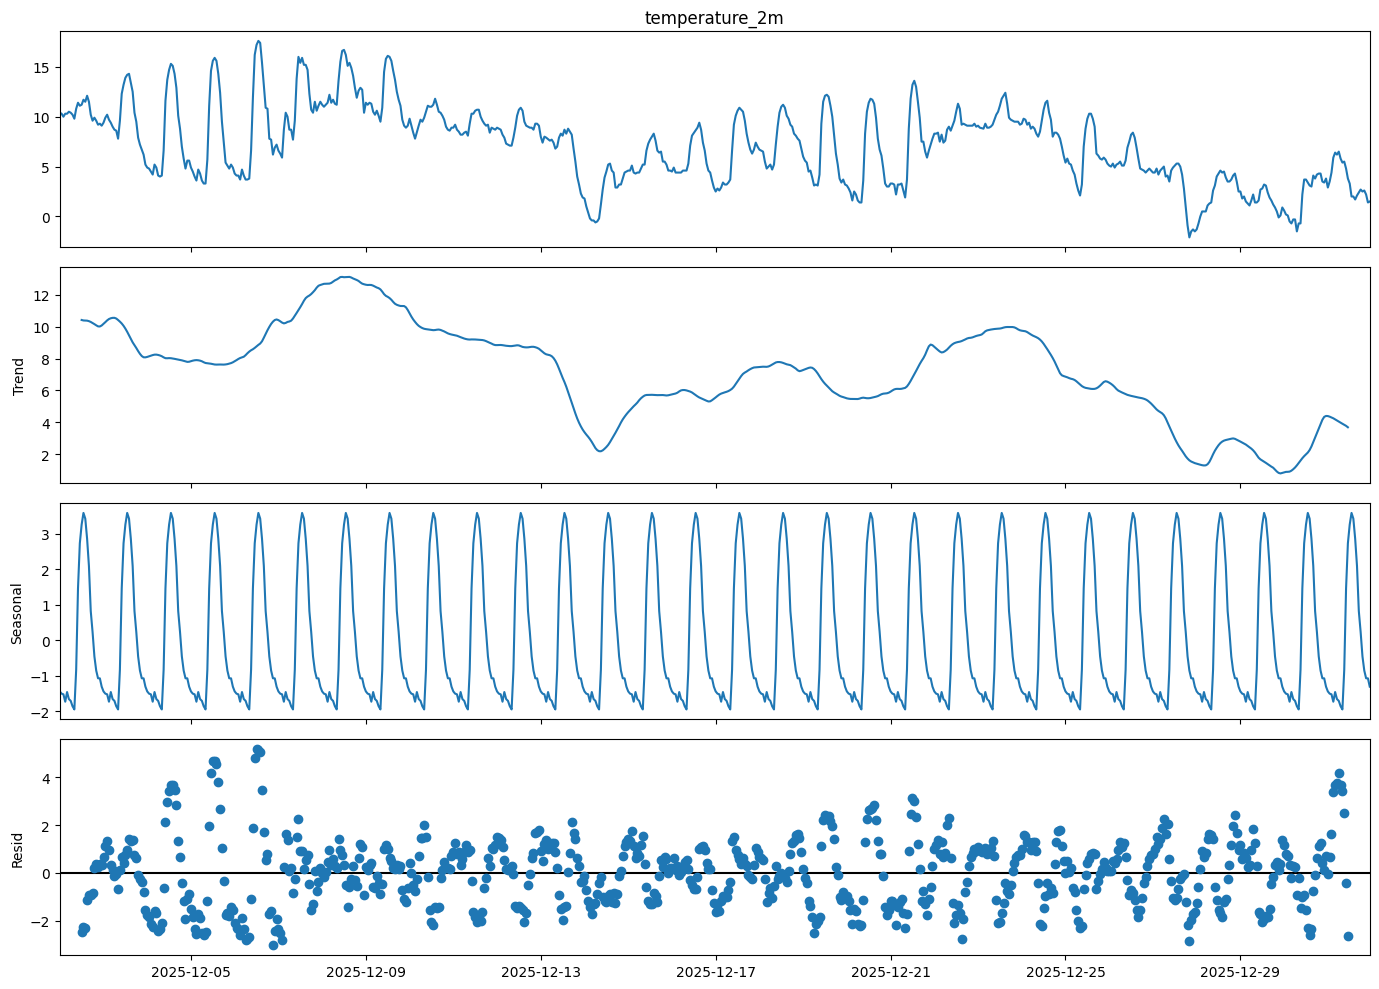

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
for city, city_df in city_dfs.items():
    city_df = city_df.set_index("ds")
    decomposition = seasonal_decompose(city_df["temperature_2m"].tail(24*30), model="additive", period=24)
    plt.rcParams["figure.figsize"] = (14, 10)
    fig = decomposition.plot()
    print(city)
    plt.show()

Прменим преобразование Фурье для выявления доминирующих периодов - ожидаем, что это будет 24 часа, так как сезонность суточная.

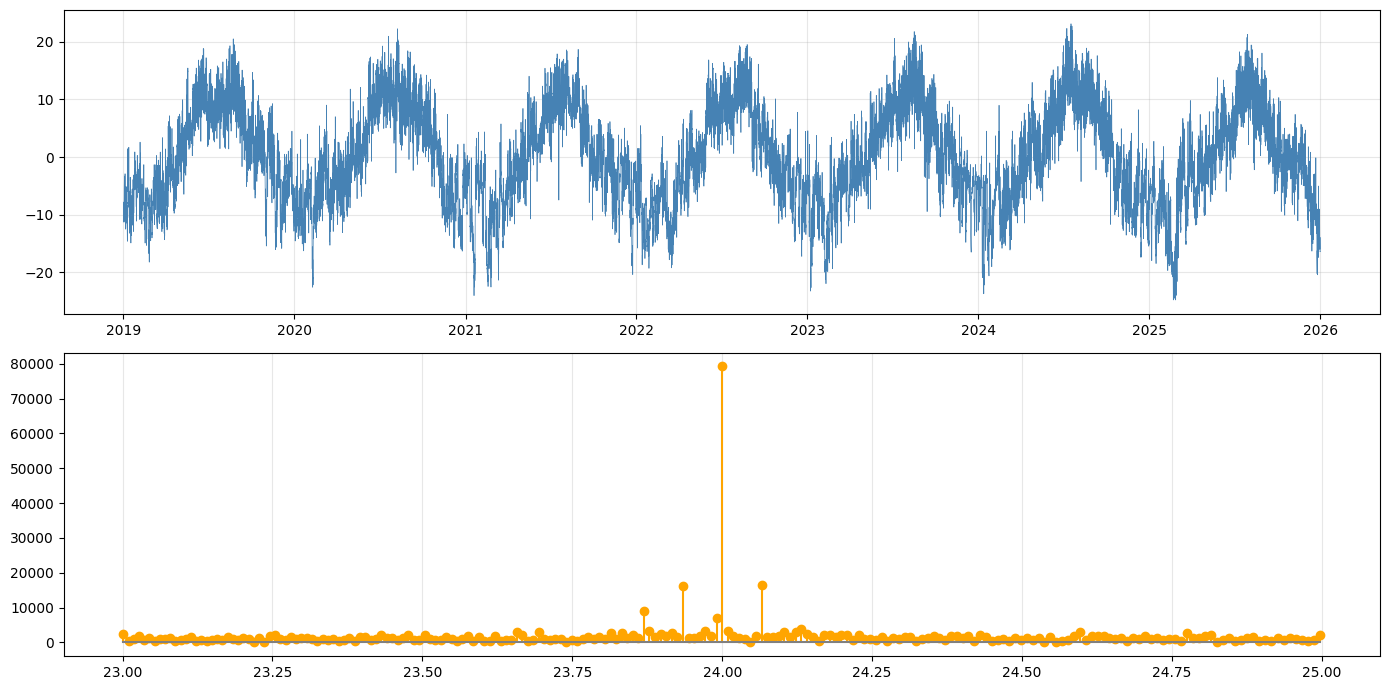

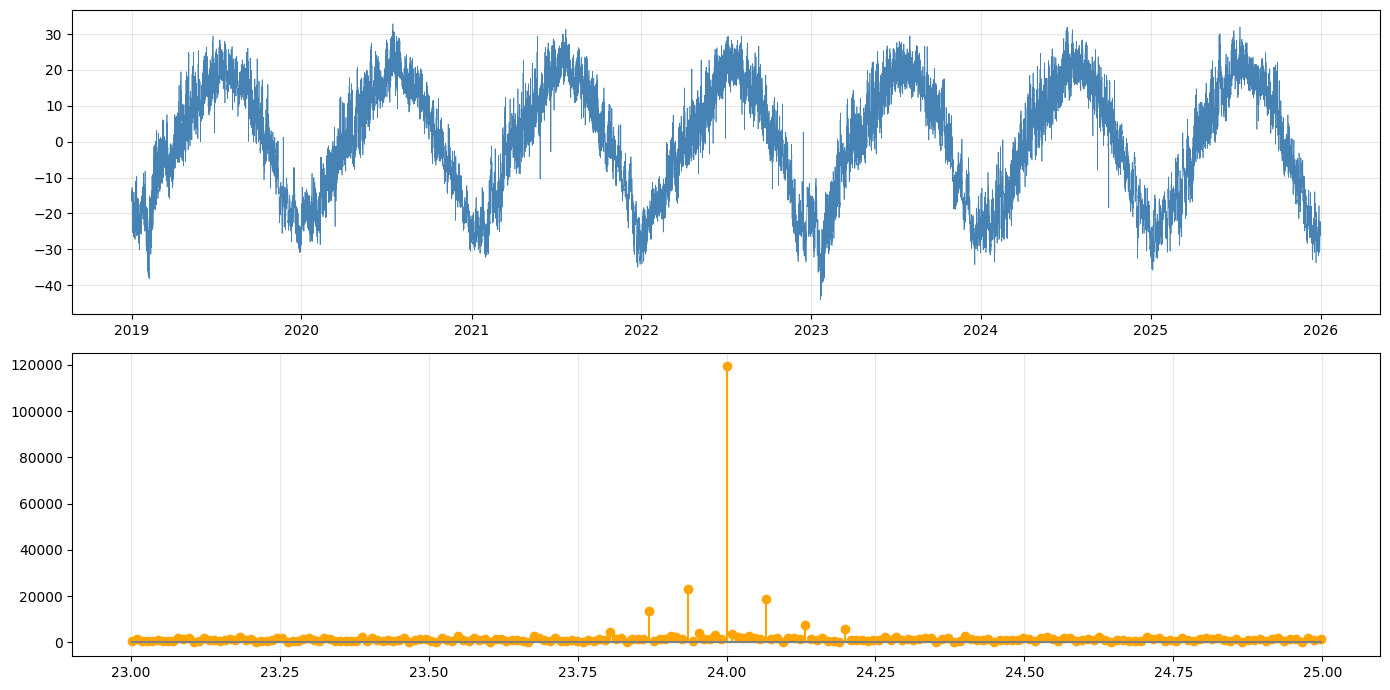

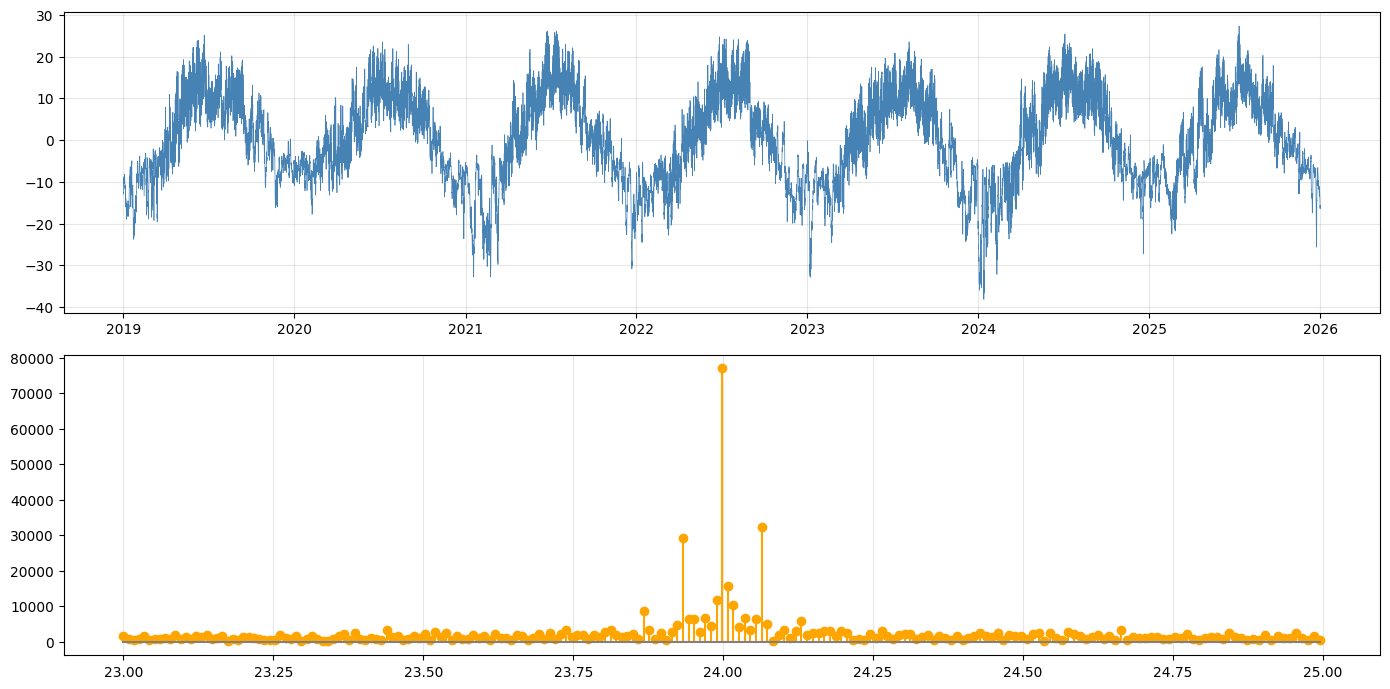

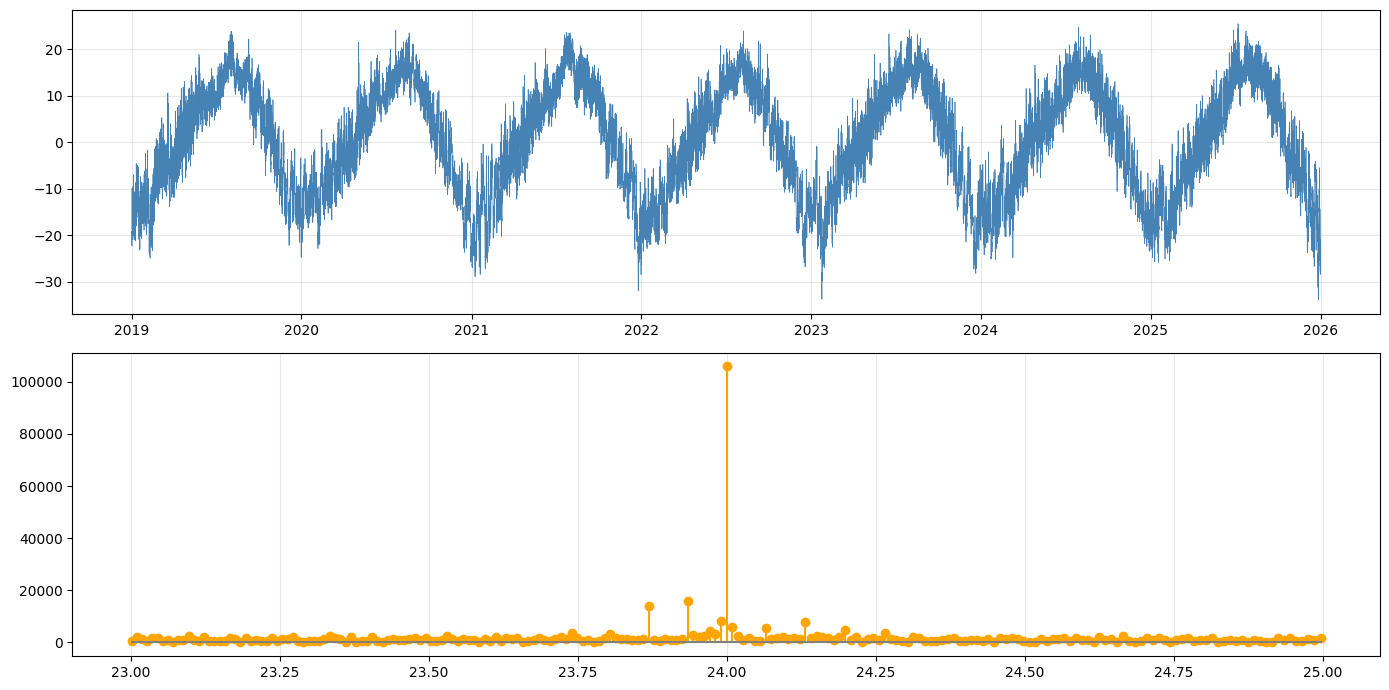

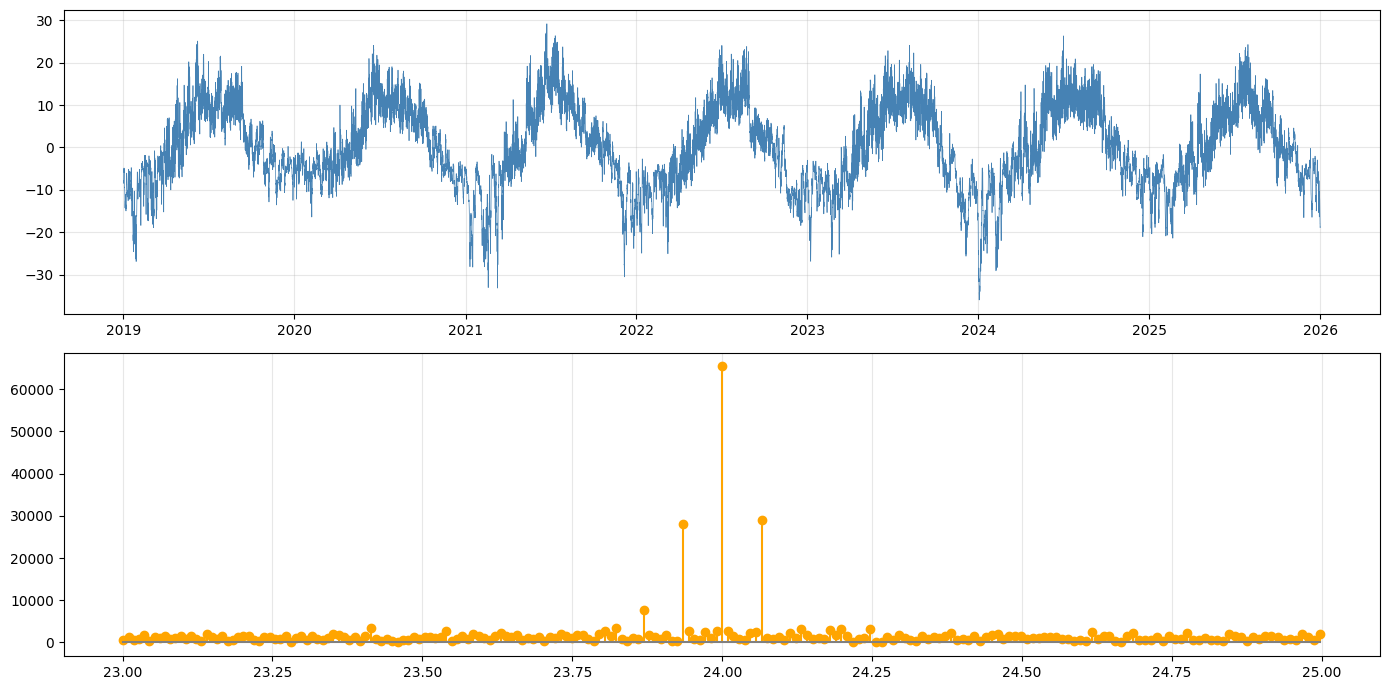

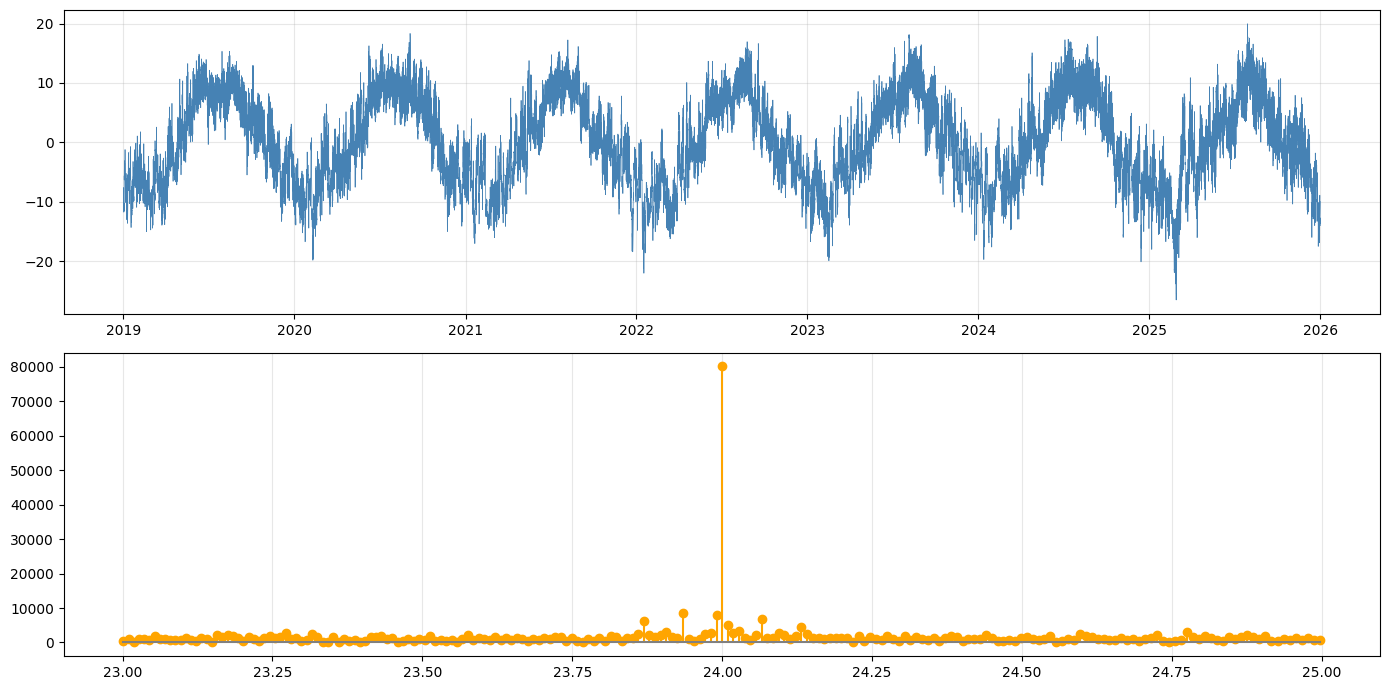

In [25]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.signal import detrend

for city, city_df in city_dfs.items():
    city_df = city_df.set_index("ds")
    temp = detrend(city_df["temperature_2m"])
    dt = 1
    n = len(temp)
    fft_vals = fft(temp)
    freqs = fftfreq(n, dt)
    power = np.abs(fft_vals[:n//2])
    freqs_pos = freqs[:n//2]
    periods = 1 / freqs_pos[freqs_pos > 0]
    power_pos = power[freqs_pos > 0]
    fig, axs = plt.subplots(2, 1, figsize=(14, 7))

    axs[0].plot(city_df["temperature_2m"].index, temp, color='steelblue', linewidth=0.5)
    axs[0].grid(True, alpha=0.3)

    mask = (periods >= 23) & (periods <= 25) 
    axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
    axs[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()



# Извлечение признаков для прогнозирования

Извлечем признаки для прогнозирования - создадим временные признаки с помощью индексв, часы и месяцы закодируем циклически, также создадим лаги температуры на две недели назад и добавим среднюю температуру за последние 2 суток. 

In [ ]:
feature_dfs = {} 
for city, city_df in city_dfs.items():
    df_feat = city_df.copy()
    df_feat = df_feat.sort_values("ds").set_index("ds")
    df_feat["hour"] = df_feat.index.hour
    df_feat["dayofweek"] = df_feat.index.dayofweek
    df_feat["month"]  = df_feat.index.month
    df_feat["dayofyear"] = df_feat.index.dayofyear
    
    df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
    df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)
    df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"] / 12)
    df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"] / 12)

    for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]:
        df_feat[f"temp_lag_{lag}"] = df_feat["temperature_2m"].shift(lag)
    
    for window in [6, 12, 24, 48]:
        rolled = df_feat["temperature_2m"].shift(1).rolling(window)
        df_feat[f"temp_roll_mean_{window}"] = rolled.mean()
    
    df_feat = df_feat.drop(columns=['city'])
    df_feat = df_feat.dropna()
    feature_dfs[city] = df_feat
    print(f"{city}: {df_feat.shape[0]} строк, {df_feat.shape[1]} признаков")
    print(feature_dfs[city].head())

Геленджик: 61032 строк, 30 признаков
                     temperature_2m  relative_humidity_2m  precipitation  \
ds                                                                         
2019-01-15 00:00:00             7.1                  88.0            0.4   
2019-01-15 01:00:00             6.9                  88.0            1.0   
2019-01-15 02:00:00             6.8                  84.0            0.7   
2019-01-15 03:00:00             6.7                  85.0            0.3   
2019-01-15 04:00:00             6.8                  85.0            0.6   

                     rain  snowfall  weathercode  wind_speed_10m  \
ds                                                                 
2019-01-15 00:00:00   0.4       0.0         51.0       22.500000   
2019-01-15 01:00:00   1.0       0.0         55.0       22.400000   
2019-01-15 02:00:00   0.7       0.0         53.0       20.600000   
2019-01-15 03:00:00   0.3       0.0         51.0       18.299999   
2019-01-15 04:00:00   

Сделаем хронологическое разделение данных на train/val/test.  

In [61]:
xy_list = []
for city, city_feat in feature_dfs.items():
    l = len(city_feat)
    tr_end = int(l * 0.8)
    val_end = int(l * 0.9)
    train_df = city_feat.iloc[:tr_end].copy()
    val_df = city_feat.iloc[tr_end:val_end].copy()
    test_df = city_feat[val_end::].copy()

    X_train = train_df.drop(columns=['temperature_2m'])
    y_train = train_df['temperature_2m']
    X_val = val_df.drop(columns=['temperature_2m'])
    y_val = val_df['temperature_2m']
    X_test  = test_df.drop(columns=['temperature_2m'])
    y_test = test_df['temperature_2m']

    xy_list.append((city, X_train, y_train, X_val, y_val, X_test, y_test))


Напишем функции для оценки качества прогнозирования: MAE - средняя абсолютная ошибка, WAPE - взвешенная абсолютная процентная ошибка, MAPE - средняя абсолютная процентная ошибка, Directional accuracy - точность предсказания направления изменения, Directional R² - коэффициент детерминации для направлений изменений. 

In [59]:
from sklearn.metrics import mean_absolute_error

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    return np.mean(true_dir == pred_dir)

def directional_r2(y_true, y_pred):
    true_dir = np.diff(y_true)
    pred_dir = np.diff(y_pred)
    corr = np.corrcoef(true_dir, pred_dir)[0, 1]
    return corr ** 2

def evaluate(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        "MAE":      round(mean_absolute_error(y_true, y_pred), 4),
        "WAPE":     round(wape(y_true, y_pred), 4),
        "MAPE":     round(mape(y_true, y_pred), 4),
        "Dir.Acc":  round(directional_accuracy(y_true, y_pred), 4),
        "Dir.R2":   round(directional_r2(y_true, y_pred), 4),
    }

# Обучение

Здесь и далее я обучаю модель для одного города - Геленджика, поскольку обучение обучение моделей происходит очень медленно. Однако это легко можно исправить, убрав break в конце каждой функции - так модели смогут обучиться отдельно для всех 6 городов. 

Обучим по очереди Decision Tree, Random Forest и LightGBM для прогнозирования температуры на 7 дней вперед. Используем optuna для подбора гиперпараметров. Используем рекурсивную стратегию и direct-стратегию. Также сохраним метрики качества и предсказания.

In [79]:
import optuna
from sklearn.tree import DecisionTreeRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

HORIZON = 24 * 7
results = []

for city, X_train, y_train, X_val, y_val, X_test, y_test in xy_list:

    # Optuna
    def obj_dt(trial):
        m = DecisionTreeRegressor(
            max_depth        = trial.suggest_int("max_depth", 3, 20),
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20),
            random_state=42)
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))
    study = optuna.create_study(direction="minimize")
    study.optimize(obj_dt, n_trials=30, show_progress_bar=True)
    p = study.best_params

    X_tr = pd.concat([X_train, X_val])
    y_tr = pd.concat([y_train, y_val])
    lag_cols = sorted([c for c in X_train.columns if c.startswith("temp_lag_")],
                      key=lambda x: int(x.split("_")[-1]))

    # Recursive
    model_rec = DecisionTreeRegressor(**p, random_state=42).fit(X_tr, y_tr)
    row = X_tr.iloc[[-1]].copy()
    preds_rec = []
    for _ in range(HORIZON):
        pred = model_rec.predict(row)[0]
        preds_rec.append(pred)
        for i in range(len(lag_cols)-1, 0, -1):
            row[lag_cols[i]] = row[lag_cols[i-1]].values
        row[lag_cols[0]] = pred

    # Direct
    preds_dir = []
    for h in range(1, HORIZON+1):
        m = DecisionTreeRegressor(**p, random_state=42).fit(X_tr.iloc[:-h], y_tr.iloc[h:])
        preds_dir.append(m.predict(X_test.iloc[[0]])[0])

    y_true = y_test.values[:HORIZON]
    
    for strategy, preds in [("Recursive", np.array(preds_rec)), ("Direct", np.array(preds_dir))]:
        results.append({
            "city": city,
            "model": "DecisionTree",
            "strategy": strategy,
            **evaluate(y_true, preds)
        })
    
    results.append({
        "city": city,
        "model": "DecisionTree",
        "strategy": "Recursive",
        "predictions": preds_rec,
        "y_true": y_true.tolist(),
    })
    
    results.append({
        "city": city,
        "model": "DecisionTree",
        "strategy": "Direct",
        "predictions": preds_dir,
        "y_true": y_true.tolist(),
    })

    print(f"{city} DecisionTree done")
    break

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 28. Best value: 0.631396: 100%|██████████| 30/30 [00:58<00:00,  1.96s/it]


Геленджик DecisionTree done


c:\Users\Екатерина\python_frameworks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Екатерина\python_frameworks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [80]:
from sklearn.ensemble import RandomForestRegressor

for city, X_train, y_train, X_val, y_val, X_test, y_test in xy_list:

    # Optuna
    def obj_rf(trial):
        m = RandomForestRegressor(
            n_estimators     = trial.suggest_int("n_estimators", 30, 80),  # было 50-200
            max_depth        = trial.suggest_int("max_depth", 5, 10),       # было 3-15
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 5), # было 1-10
            random_state=42, n_jobs=-1)
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))
    study = optuna.create_study(direction="minimize")
    study.optimize(obj_rf, n_trials=10, show_progress_bar=True)  # было 30
    p = study.best_params

    X_tr = pd.concat([X_train, X_val])
    y_tr = pd.concat([y_train, y_val])
    lag_cols = sorted([c for c in X_train.columns if c.startswith("temp_lag_")],
                      key=lambda x: int(x.split("_")[-1]))

    # Recursive
    model_rec = RandomForestRegressor(**p, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    row = X_tr.iloc[[-1]].copy()
    preds_rec = []
    for _ in range(HORIZON):
        pred = model_rec.predict(row)[0]
        preds_rec.append(pred)
        for i in range(len(lag_cols)-1, 0, -1):
            row[lag_cols[i]] = row[lag_cols[i-1]].values
        row[lag_cols[0]] = pred

    # Direct
    preds_dir = []
    for h in range(1, HORIZON+1):
        m = RandomForestRegressor(**p, random_state=42, n_jobs=-1).fit(X_tr.iloc[:-h], y_tr.iloc[h:])
        preds_dir.append(m.predict(X_test.iloc[[0]])[0])

    y_true = y_test.values[:HORIZON]

    for strategy, preds in [("Recursive", np.array(preds_rec)), ("Direct", np.array(preds_dir))]:
        results.append({
            "city": city,
            "model": "RandomForest",
            "strategy": strategy,
            **evaluate(y_true, preds)
        })
    
    results.append({
        "city": city,
        "model": "RandomForest",
        "strategy": "Recursive",
        "predictions": preds_rec,
        "y_true": y_true.tolist(),
    })
    
    results.append({
        "city": city,
        "model": "RandomForest",
        "strategy": "Direct",
        "predictions": preds_dir,
        "y_true": y_true.tolist(),
    })

    print(f"{city} RandomForest done")
    break

  0%|          | 0/10 [00:00<?, ?it/s]

Best trial: 8. Best value: 0.569357: 100%|██████████| 10/10 [01:08<00:00,  6.87s/it]


Геленджик RandomForest done


In [81]:
import lightgbm as lgb

for city, X_train, y_train, X_val, y_val, X_test, y_test in xy_list:

    # Optuna
    def obj_gb(trial):
        m = lgb.LGBMRegressor(
            n_estimators  = trial.suggest_int("n_estimators", 50, 200),
            max_depth     = trial.suggest_int("max_depth", 2, 6),
            learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            random_state=42,
            verbose=-1
        )
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))
    study = optuna.create_study(direction="minimize")
    study.optimize(obj_gb, n_trials=30, show_progress_bar=True)
    p = study.best_params

    X_tr = pd.concat([X_train, X_val])
    y_tr = pd.concat([y_train, y_val])
    lag_cols = sorted([c for c in X_train.columns if c.startswith("temp_lag_")],
                      key=lambda x: int(x.split("_")[-1]))

    # Recursive
    model_rec = lgb.LGBMRegressor(**p, random_state=42, verbose=-1).fit(X_tr, y_tr)
    row = X_tr.iloc[[-1]].copy()
    preds_rec = []
    for _ in range(HORIZON):
        pred = model_rec.predict(row)[0]
        preds_rec.append(pred)
        for i in range(len(lag_cols)-1, 0, -1):
            row[lag_cols[i]] = row[lag_cols[i-1]].values
        row[lag_cols[0]] = pred

    # Direct
    preds_dir = []
    for h in range(1, HORIZON+1):
        m = lgb.LGBMRegressor(**p, random_state=42, verbose=-1).fit(X_tr.iloc[:-h], y_tr.iloc[h:])
        preds_dir.append(m.predict(X_test.iloc[[0]])[0])

    y_true = y_test.values[:HORIZON]

    for strategy, preds in [("Recursive", np.array(preds_rec)), ("Direct", np.array(preds_dir))]:
        results.append({
            "city": city,
            "model": "LightGBM",
            "strategy": strategy,
            **evaluate(y_true, preds)
        })
    
    results.append({
        "city": city,
        "model": "LightGBM",
        "strategy": "Recursive",
        "predictions": preds_rec,
        "y_true": y_true.tolist(),
    })
    
    results.append({
        "city": city,
        "model": "LightGBM",
        "strategy": "Direct",
        "predictions": preds_dir,
        "y_true": y_true.tolist(),
    })

    print(f"{city} LightGBM done")
    break

Best trial: 23. Best value: 0.544373: 100%|██████████| 30/30 [00:17<00:00,  1.73it/s]


Геленджик LightGBM done


Теперь провизуализируем полученные результаты и сравним показания метрик. 

C:\Users\Екатерина\AppData\Local\Temp\ipykernel_27504\1530693738.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(range(len(y_true_values)), y_true_values, 'k-', linewidth=2, label='Факт', color='black')


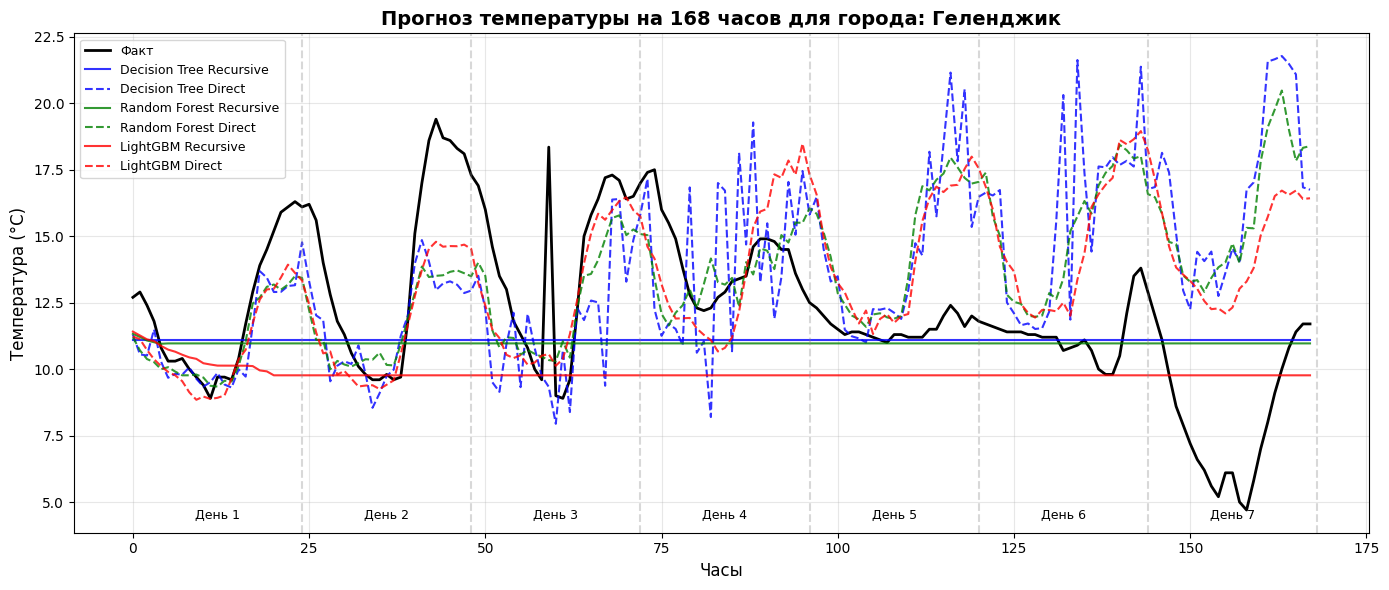


СРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ
      Модель Стратегия    MAE   WAPE   MAPE  Dir.Acc  Dir.R2
DecisionTree Recursive 2.3564 0.1937 0.2025   0.1078     NaN
DecisionTree    Direct 3.5458 0.2915 0.3441   0.4790  0.0107
RandomForest Recursive 2.4010 0.1974 0.2041   0.3832  0.0017
RandomForest    Direct 3.0597 0.2515 0.3029   0.5389  0.0475
    LightGBM Recursive 2.9747 0.2445 0.2351   0.1497  0.0002
    LightGBM    Direct 2.8457 0.2339 0.2755   0.5808  0.1164


In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dt_rec_preds = None
dt_dir_preds = None
rf_rec_preds = None
rf_dir_preds = None
lgb_rec_preds = None
lgb_dir_preds = None
y_true_values = None

for res in results:
    if "predictions" in res:
        if res["model"] == "DecisionTree" and res["strategy"] == "Recursive":
            dt_rec_preds = res["predictions"]
        elif res["model"] == "DecisionTree" and res["strategy"] == "Direct":
            dt_dir_preds = res["predictions"]
        elif res["model"] == "RandomForest" and res["strategy"] == "Recursive":
            rf_rec_preds = res["predictions"]
        elif res["model"] == "RandomForest" and res["strategy"] == "Direct":
            rf_dir_preds = res["predictions"]
        elif res["model"] == "LightGBM" and res["strategy"] == "Recursive":
            lgb_rec_preds = res["predictions"]
        elif res["model"] == "LightGBM" and res["strategy"] == "Direct":
            lgb_dir_preds = res["predictions"]
        
        if y_true_values is None:
            y_true_values = res["y_true"]

plt.figure(figsize=(14, 6))

if y_true_values:
    plt.plot(range(len(y_true_values)), y_true_values, 'k-', linewidth=2, label='Факт', color='black')

if dt_rec_preds:
    plt.plot(range(len(dt_rec_preds)), dt_rec_preds, 'b-', linewidth=1.5, label='Decision Tree Recursive', alpha=0.8)
if dt_dir_preds:
    plt.plot(range(len(dt_dir_preds)), dt_dir_preds, 'b--', linewidth=1.5, label='Decision Tree Direct', alpha=0.8)

if rf_rec_preds:
    plt.plot(range(len(rf_rec_preds)), rf_rec_preds, 'g-', linewidth=1.5, label='Random Forest Recursive', alpha=0.8)
if rf_dir_preds:
    plt.plot(range(len(rf_dir_preds)), rf_dir_preds, 'g--', linewidth=1.5, label='Random Forest Direct', alpha=0.8)

if lgb_rec_preds:
    plt.plot(range(len(lgb_rec_preds)), lgb_rec_preds, 'r-', linewidth=1.5, label='LightGBM Recursive', alpha=0.8)
if lgb_dir_preds:
    plt.plot(range(len(lgb_dir_preds)), lgb_dir_preds, 'r--', linewidth=1.5, label='LightGBM Direct', alpha=0.8)

plt.xlabel('Часы', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.title('Прогноз температуры на 168 часов для города: Геленджик', fontsize=14, fontweight='bold')

for day in range(1, 8):
    plt.axvline(x=day*24, color='gray', linestyle='--', alpha=0.3)
    plt.text(day*24 - 12, plt.ylim()[0] + 0.5, f'День {day}', ha='center', fontsize=9)

plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("\nСРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ")


metrics_data = []
for res in results:
    if "MAE" in res:
        metrics_data.append({
            "Модель": res["model"],
            "Стратегия": res["strategy"],
            "MAE": res["MAE"],
            "WAPE": res["WAPE"],
            "MAPE": res["MAPE"],
            "Dir.Acc": res["Dir.Acc"],
            "Dir.R2": res["Dir.R2"]
        })

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))


На основе полученных данных можно сделать следующие выводы: лучший результат показала модель Decision Tree с рекурсивной стратегией, достигнув MAE = 2.356, что означает среднюю ошибку прогноза около 2.3 градусов. Random Forest оказался близок по качеству (MAE = 2.40), а LightGBM показал чуть худший результат (MAE = 2.97). 

WAPE показывает относительную ошибку прогноза, взвешенную по величине реальных значений. Лучшее значение также у Decision Tree с рекурсивной стратегией. 

MAPE показывает на сколько процентов в среднем модель ошибается относительно реального значения - лучшее значение у Decision Tree с рекурсивной стратегией.

В предсказании направления изменения температуры - Direction Accuracy лучше всего LightGBM Direct с точностью 58%. 

Dir.R2 показывает насколько хорошо модель объясняет рост/уменьшение температуры - лучшее значение у LightGBM Direct.

Рекурсивная стратегия превосходит direct для всех моделей. 



На графике видно, что рекурсивная стратегия значительно лучше повторяет общий тренд и динамику реальной температуры, чем Direct стратегия. Direct для Decision Tree и Random Forest дает ступенчатые, неестественные прогнозы (красные и синие полосы), а LGBM справляется лучше – линия более гладкая и ближе к реальным значениям. 

Все рекурсивные прогнозы имеют схожую динамику и в целом адекватно отражают поведение температуры. Первый день прогноза наиболее точен для всех моделей – линии близки к факту. К пятому-седьмому дню ошибка накапливается, что характерно для рекурсивного прогнозирования.